In [1]:
import os
import sys
os.chdir("../")
sys.path.insert(0, os.path.abspath("."))
configs_file = "train_cvit"

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
jax.config.update("jax_default_matmul_precision", "highest")
# jax.config.update("jax_default_matmul_precision", "float32") 
import jax.numpy as jnp
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat

from ldc.configs import load_configs
configs = load_configs(configs_file)


from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})

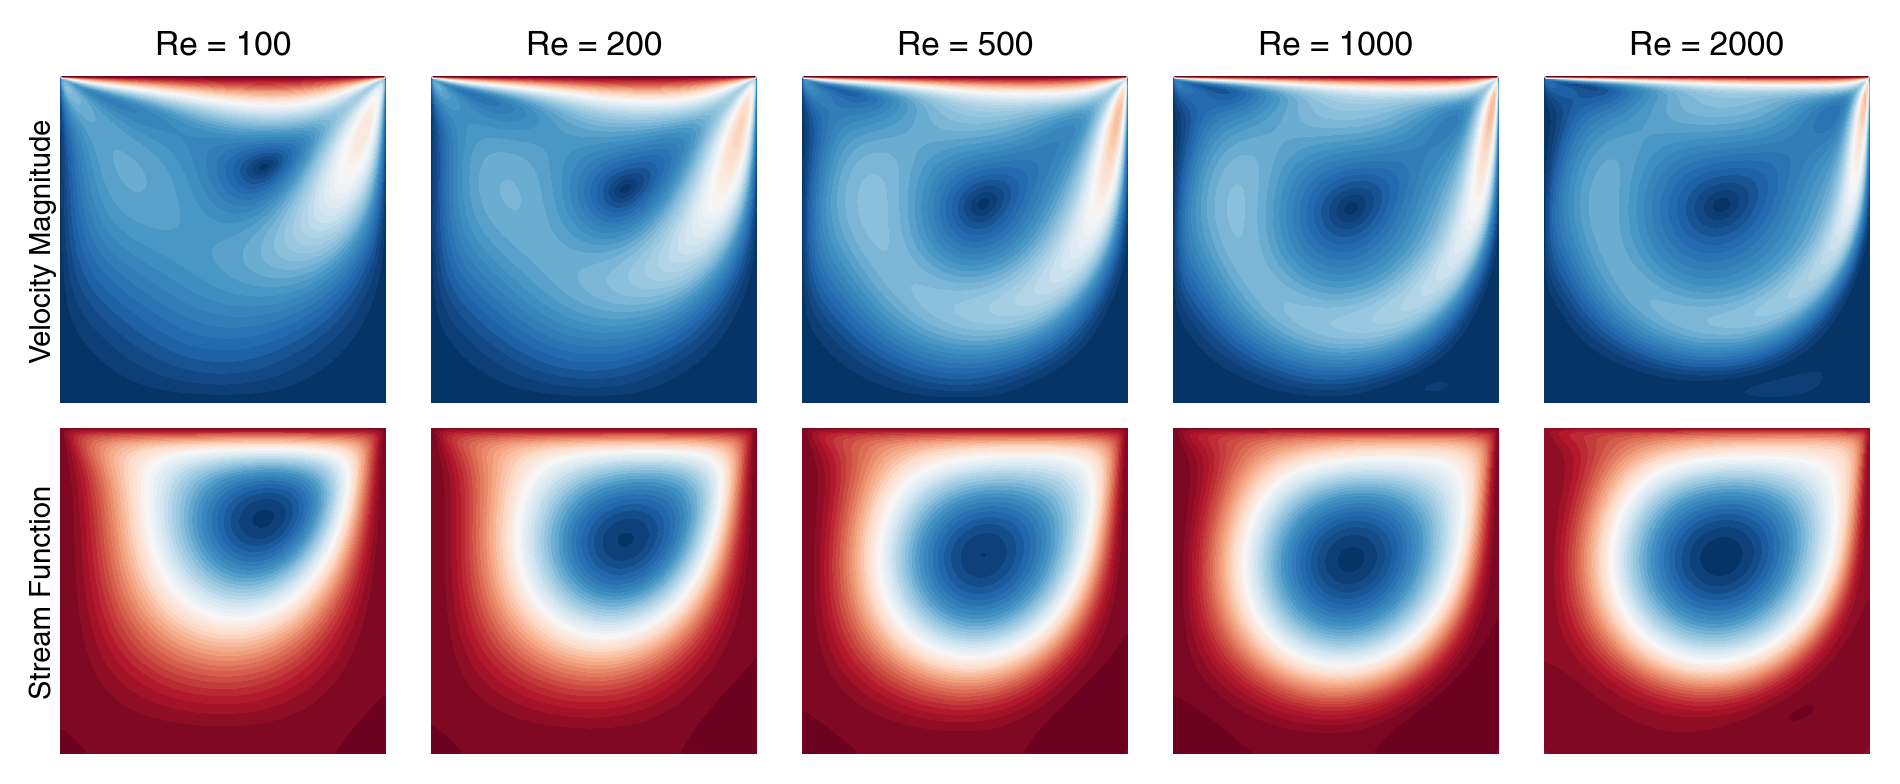

In [3]:
re_vals = [100, 200, 500, 1000, 2000]
data_paths = [f"./data/ldc/flow_fields_Re{re_val}_N128.npz" for re_val in re_vals]
# x = jnp.linspace(0, 1, 128)
# y = jnp.linspace(0, 1, 128)
# X, Y = jnp.meshgrid(x, y, indexing="xy")
data_sample = jnp.load(data_paths[0])
X = data_sample["X"]
Y = data_sample["Y"]

fig, axes = plt.subplots(
    nrows=2,
    ncols=len(re_vals),
    figsize=(1.25 * len(re_vals), 1.25*2),
    constrained_layout=True,
)
for idx, (re_val, data_path) in enumerate(zip(re_vals, data_paths)):
    data = jnp.load(data_path)
    u = data["u"]
    v = data["v"]
    speed = jnp.sqrt(u**2 + v**2)
    ax = axes[0, idx]
    ax.contourf(
        X, Y, speed,
        levels=50,
        cmap="RdBu_r",
        vmin=0,
        vmax=1.0,
    )
    ax.set_axis_off()
    ax.text(
        0.5, 1.05,
        f"Re = {re_val}",
        fontsize=8,
        ha="center",
        va="bottom",
        transform=ax.transAxes,
    )
    ax.set_aspect("equal")
    
    ax = axes[1, idx]
    psi = data["psi"]
    ax.contourf(
        X, Y, psi,
        levels=50,
        cmap="RdBu_r",
    )
    ax.set_axis_off()
    ax.set_aspect("equal")
    
    if idx == 0:
        axes[0, idx].text(
            -0.05, 0.5,
            "Velocity Magnitude",
            fontsize=7,
            rotation=90,
            ha="center",
            va="center",
            transform=axes[0, idx].transAxes,
        )
        axes[1, idx].text(
            -0.05, 0.5,
            "Stream Function",
            fontsize=7,
            rotation=90,
            ha="center",
            va="center",
            transform=axes[1, idx].transAxes,
        )

In [4]:
from ldc.simplified_cvit import CViT

key = jax.random.PRNGKey(0)
model_params = configs.model_params


# weight = "/root/autodl-tmp/tf-logs/ldc/cvit/baseline-0126-mlplayer3/model_epoch_23000.eqx"
# model_params.update({
#     "dec_depth": 2,
#     "dec_mlp_arch": "mlp"
# })

# weight = "/root/autodl-tmp/tf-logs/ldc/cvit/baseline-0126-modifiedmlp_layer3/model_epoch_12000.eqx"
# model_params.update({
#     "dec_depth": 2,
# })

# weight = "/root/autodl-tmp/tf-logs/ldc/cvit/20260126-165653/model_epoch_8000.eqx"
# weight = "/root/autodl-tmp/tf-logs/ldc/cvit/baseline-0126-renold100_2000/model_epoch_20000.eqx"
# weight = "/root/autodl-tmp/tf-logs/ldc/cvit/baseline-0127-reynold50_1000-linearsampling/model_epoch_26000.eqx"
# weight = "/root/autodl-tmp/tf-logs/ldc/cvit/baseline-0127-reynold50_1000-logspacesampling/model_epoch_30000.eqx"
# weight = "/root/autodl-tmp/tf-logs/ldc/cvit/baseline-0127-reynold50_1000-schedual_free/model_epoch_20000.eqx"
weight = "/root/autodl-tmp/tf-logs/ldc/cvit/SOTA-0205/model_epoch_33000.eqx"



model_skeleton = CViT(
    key,
    **model_params,
)
model = eqx.tree_deserialise_leaves(weight, model_skeleton)

In [5]:
data.keys()

KeysView(NpzFile './data/ldc/flow_fields_Re2000_N128.npz' with keys: x, y, X, Y, psi...)

In [6]:
# Nx = configs.Nx
# Ny = configs.Ny
Nx = 256
Ny = 256
data = jnp.load(configs.data_dir + f"/ldc_solutions_Re50-1000_N{Nx}.npz")
X = data["X"]
Y = data["Y"]
coords = jnp.stack([
    X.reshape(-1),
    Y.reshape(-1)
], axis=-1)  # (Ny*Nx, 2)
target_reynold = data["Re"]
ref_data = data["data"]
target_reynold = target_reynold.reshape(-1, 1)  # (B, 1)

In [7]:

target_reynold_normed = configs.normalize_re(target_reynold)
sols = jax.vmap(
    model, in_axes=(0, None)
)(target_reynold_normed, coords)  # (B, Ny*Nx, 3)

B, _, C = sols.shape
H = Ny
W = Nx
sols = rearrange(sols, "B (H W) C -> B C H W", H=int(H), W=int(W))  # (B, 3, H, W)
sols = sols[:, :2, ...]
# mask 左上和右上角的奇点，把u, v, speed对应位置设为0
eps = 1e-2
# mask = (X > 1 - eps) & (Y > 1 - eps) | (X < eps) & (Y > 1 - eps)
# sols = jnp.where(mask[None, None, :, :], 0.0, sols)
# ref_data = jnp.where(mask[None, None, :, :], 0.0, ref_data)
l2 = jnp.sqrt(jnp.mean((sols - ref_data)**2, axis=(-1, -2))) / jnp.sqrt(jnp.mean(ref_data**2, axis=(-1, -2)))
l2 = jnp.mean(l2)
print("L2 relative error:", l2)

L2 relative error: 0.07068687


Text(0.5, 0, 'Reynolds Number')

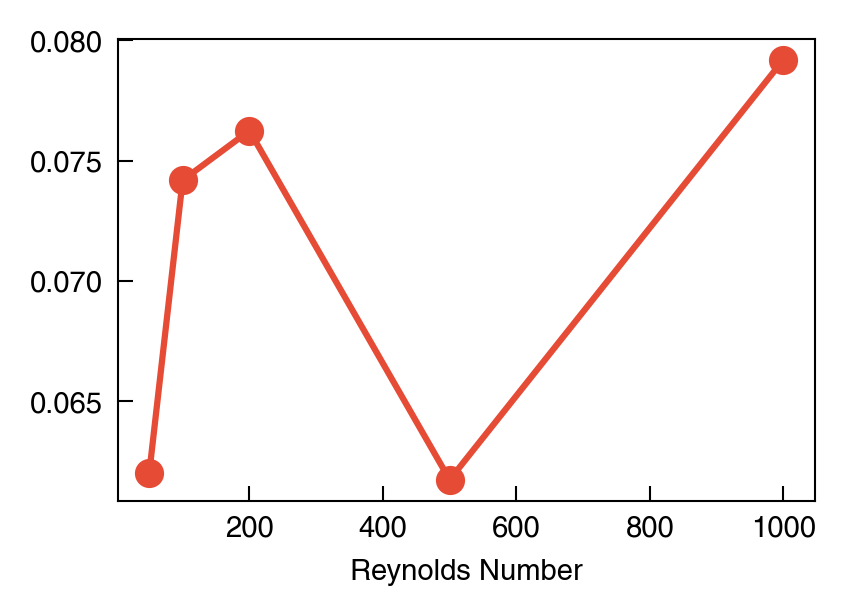

In [8]:
# Re-wise l2 error
l2_per_re = jnp.sqrt(jnp.mean((sols - ref_data)**2, axis=(-1, -2))) / jnp.sqrt(jnp.mean(ref_data**2, axis=(-1, -2)))
l2_per_re = jnp.mean(l2_per_re, axis=1)
fig, ax = plt.subplots(figsize=(3, 2))
ax.plot(target_reynold[:, 0], l2_per_re, marker="o")
ax.set_xlabel("Reynolds Number")

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


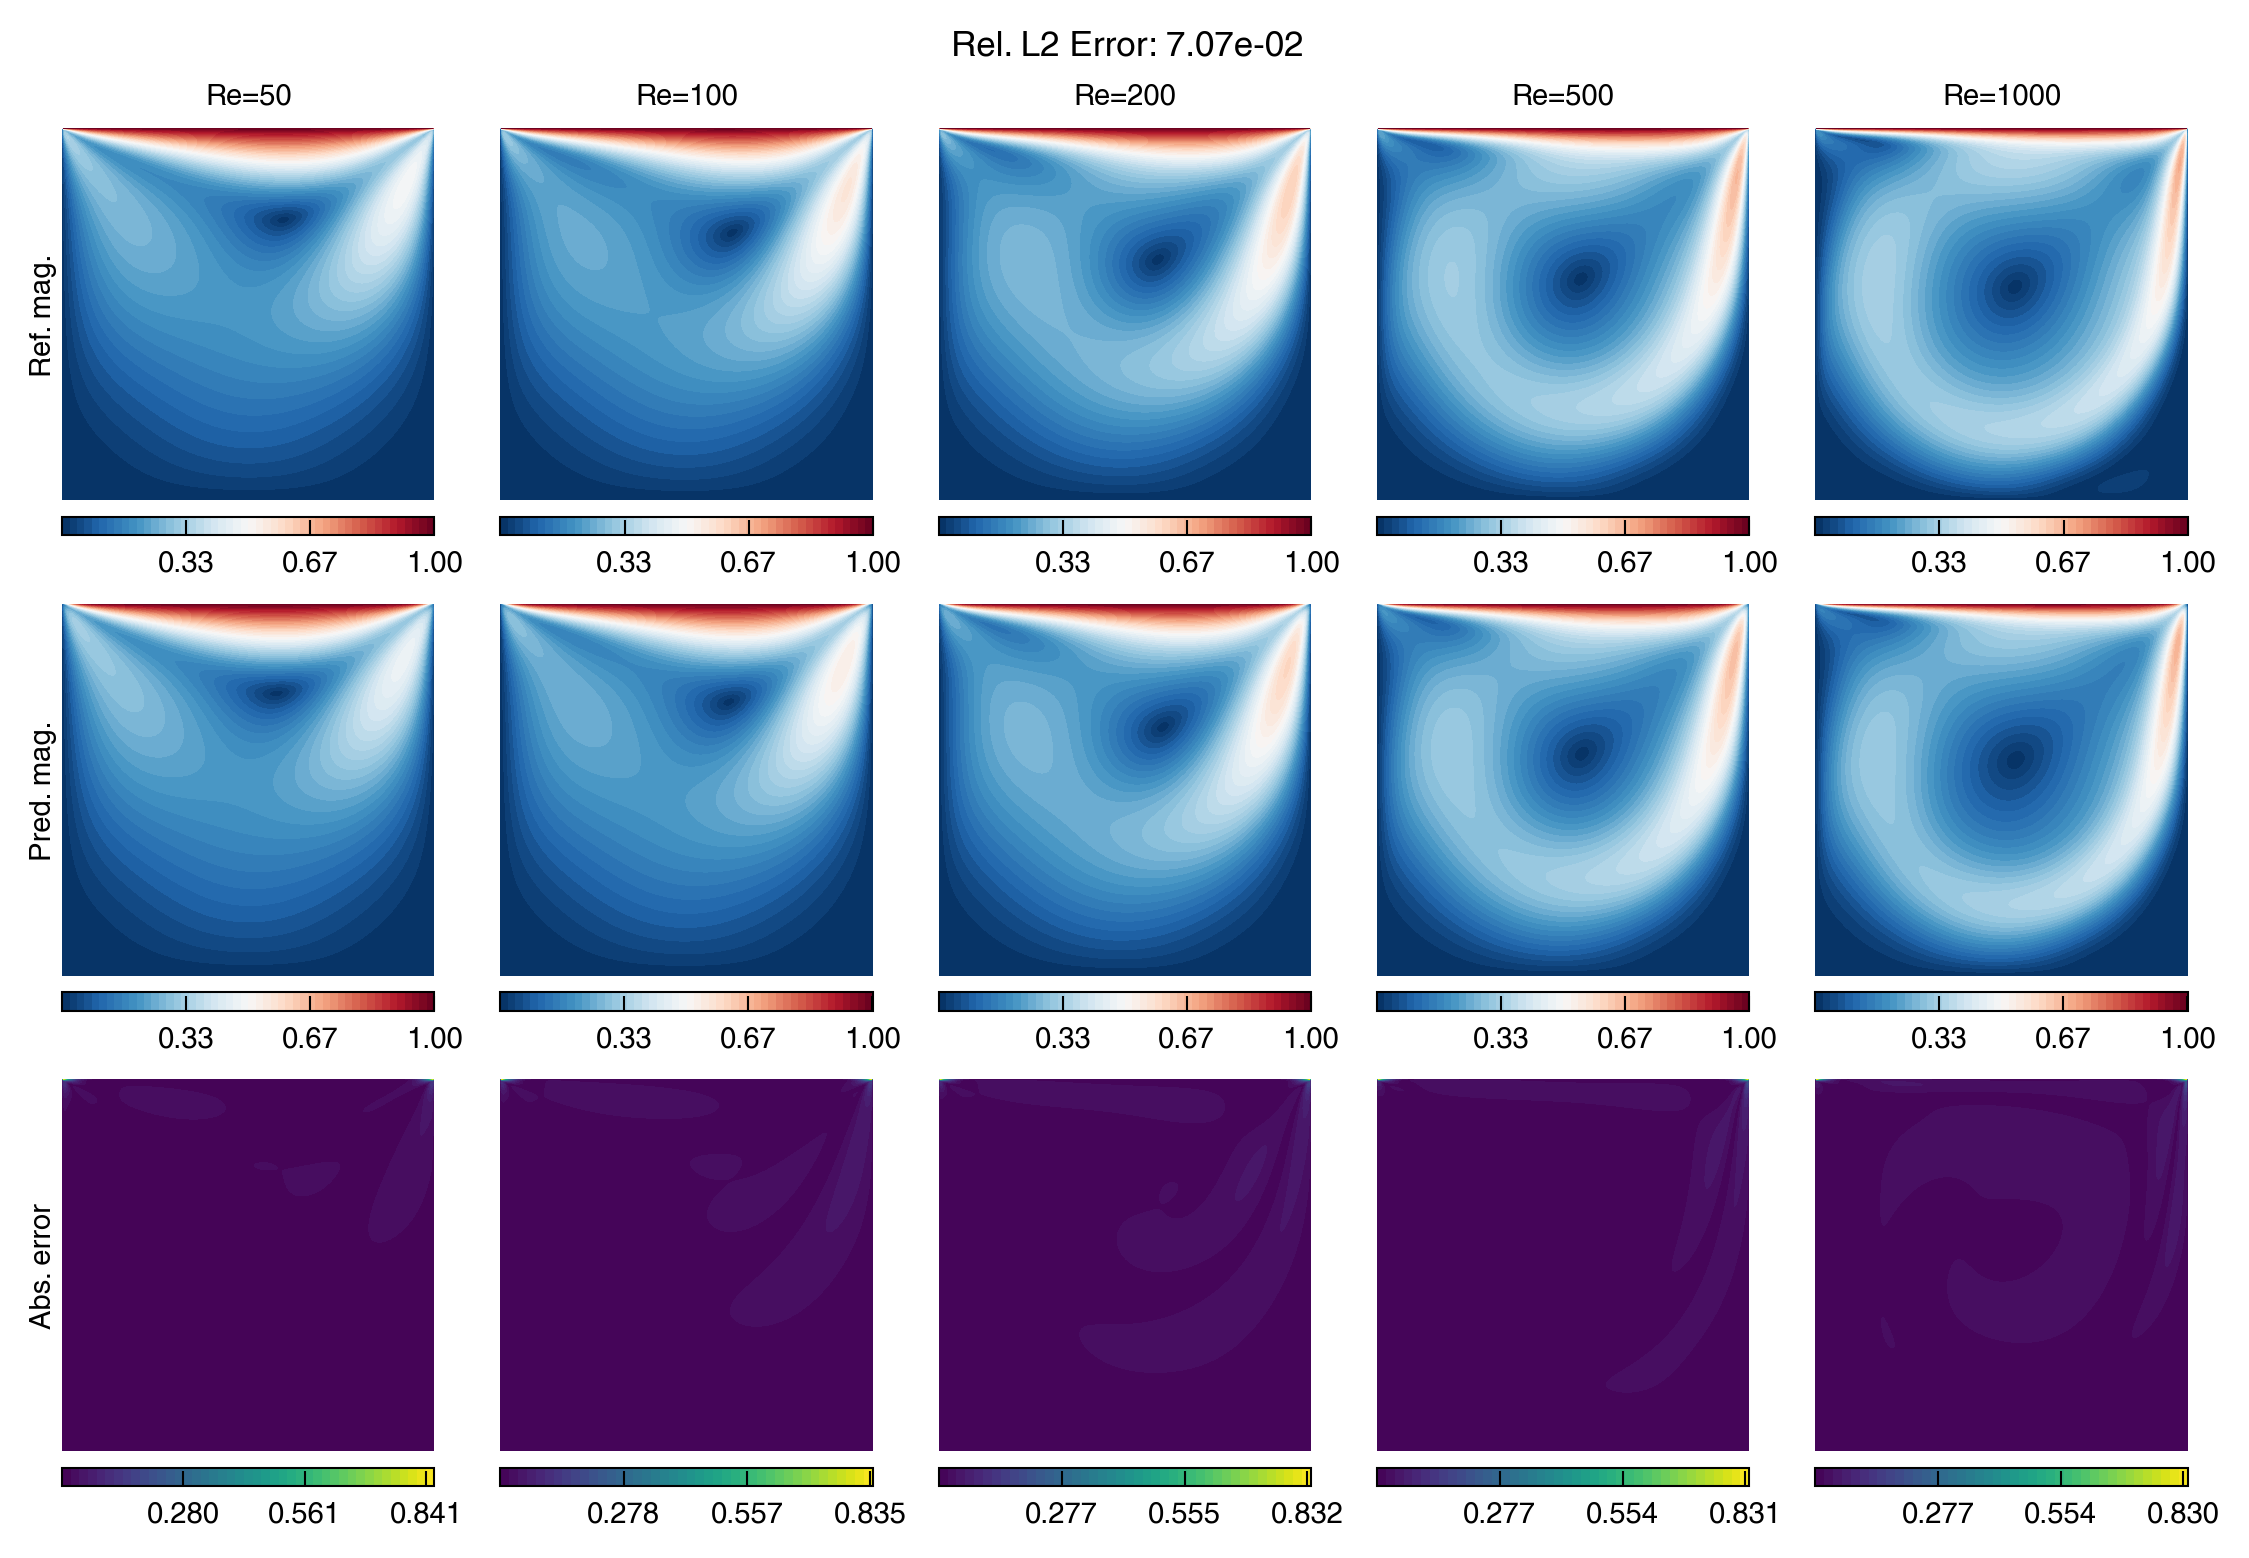

In [10]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=B,
    figsize=(1.5 * B, 5),
    subplot_kw={"aspect": "equal",},
)

for i, this_reynold in enumerate(target_reynold):
    ax = axes[0, i]
    ax.set_axis_off()

    ref_speed = jnp.sqrt(ref_data[i, 0, :, :]**2 + ref_data[i, 1, :, :]**2)
    ref_cont = ax.contourf(
        X, Y, ref_speed, levels=50, cmap="RdBu_r",
        vmin=0, vmax=1.0
    )
    fig.colorbar(ref_cont, ax=ax, fraction=0.046, pad=0.04, orientation="horizontal",
                 format="%.2f", ticks=jnp.linspace(0, jnp.max(ref_speed), num=4)[1:])
    ax.text(
        0.5, 1.05, f"Re={int(this_reynold[0])}", 
        transform=ax.transAxes,
        ha="center", va="bottom",
    )
    
    ax = axes[1, i]
    ax.set_axis_off()
    speed = jnp.sqrt(sols[i, 0, :, :]**2 + sols[i, 1, :, :]**2)
    pred_cont = ax.contourf(
        X, Y, speed, levels=50, cmap="RdBu_r",
        vmin=0, vmax=1.0
    )
    fig.colorbar(pred_cont, ax=ax, fraction=0.046, pad=0.04, orientation="horizontal",
                 format="%.2f", ticks=jnp.linspace(0, jnp.max(speed), num=4)[1:])
    
    ax = axes[2, i]
    ax.set_axis_off()
    diff = jnp.abs(ref_speed - speed)
    diff_cont = ax.contourf(X, Y, diff, levels=50, cmap="viridis",)
    colorbar = fig.colorbar(
        diff_cont, ax=ax, fraction=0.046, pad=0.04, orientation="horizontal",
        format="%.3f", ticks=jnp.linspace(0, jnp.max(diff),
                                          num=4)[1:]
    ) 
    
    if i == 0:
        axes[0, i].text(
            -0.05, 0.5, "Ref. mag.",
            transform=axes[0, i].transAxes,
            rotation=90, ha="center", va="center",
        )
        axes[1, i].text(
            -0.05, 0.5, "Pred. mag.",
            transform=axes[1, i].transAxes,
            rotation=90, ha="center", va="center",
        )
        axes[2, i].text(
            -0.05, 0.5, "Abs. error",
            transform=axes[2, i].transAxes,
            rotation=90, ha="center", va="center",
        )
fig.tight_layout()
fig.suptitle("Rel. L2 Error: %.2e" % l2, y=1.02)
fig.savefig("./figures/ldc_solution_field.png", dpi=300, bbox_inches="tight", pad_inches=0.0)
fig.savefig("./figures/ldc_solution_field.pdf", dpi=300, bbox_inches="tight", pad_inches=0.0)

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


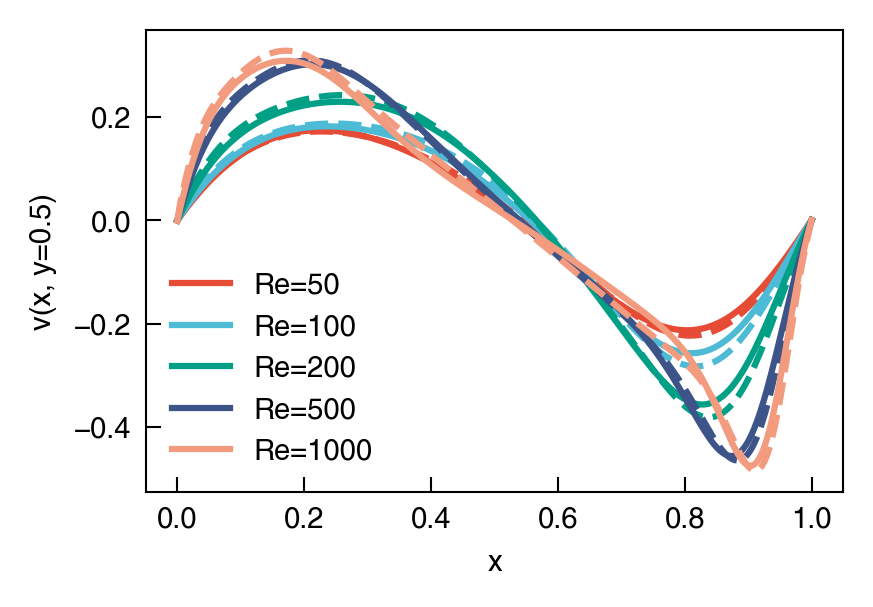

In [12]:
x = jnp.linspace(0, 1, Nx)
y = jnp.linspace(0, 1, Ny)
# 绘制 v 在 y=0.5 处的剖面图
y_index = Ny // 2  # y=0.5 对应的索引
fig, ax = plt.subplots(figsize=(3, 2))
for i, this_reynold in enumerate(target_reynold):

    plt.plot(
        x,
        ref_data[i, 1, y_index, :],
        # label=f"Ref. Re={int(this_reynold[0])}",
        linestyle="--",
        color=f"C{i}",
    )
    
    plt.plot(
        x,
        sols[i, 1, y_index, :],
        label=f"Re={int(this_reynold[0])}",
        linestyle="-",
        color=f"C{i}",
    )
ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("v(x, y=0.5)")
fig.savefig("./figures/ldc_velocity_profile_v.png", dpi=300, bbox_inches="tight", pad_inches=0.0)
fig.savefig("./figures/ldc_velocity_profile_v.pdf", dpi=300, bbox_inches="tight", pad_inches=0.0)

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


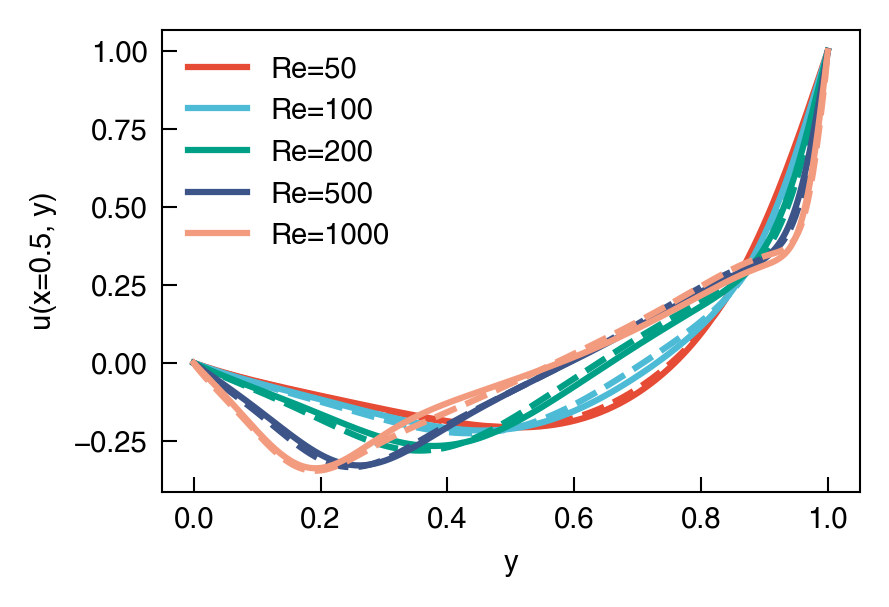

In [13]:
# 绘制 v 在 x=0.5 处的剖面图
x_index = Nx // 2  # x=0.5 对应的索引
# plt.figure(figsize=(3, 2))
fig, ax = plt.subplots(figsize=(3, 2))
for i, this_reynold in enumerate(target_reynold):

    ax.plot(
        y,
        ref_data[i, 0, :, x_index],
        # label=f"Ref. Re={int(this_reynold[0])}",
        linestyle="--",
        color=f"C{i}",
    )
    
    ax.plot(
        y,
        sols[i, 0, :, x_index],
        label=f"Re={int(this_reynold[0])}",
        linestyle="-",
        color=f"C{i}",
    )
ax.legend()
ax.set_xlabel("y")
ax.set_ylabel("u(x=0.5, y)")
fig.savefig("./figures/ldc_velocity_profile_u.png", dpi=300, bbox_inches="tight", pad_inches=0.0)
fig.savefig("./figures/ldc_velocity_profile_u.pdf", dpi=300, bbox_inches="tight", pad_inches=0.0)

In [14]:
epochs = jnp.arange(0, 33001, configs.save_every)

# model_weight_template = "/root/autodl-tmp/tf-logs/ldc/cvit/baseline-0127-reynold50_1000-schedual_free/model_epoch_{}.eqx"
# model_weight_template = "/root/autodl-tmp/tf-logs/ldc/cvit/baseline-0127-reynold50_1000-logspacesampling/model_epoch_{}.eqx"
model_weight_template = "/root/autodl-tmp/tf-logs/ldc/cvit/SOTA-0205/model_epoch_{}.eqx"
error_log = []
# mask 左上和右上角的奇点，把u, v, speed对应位置设为0
eps = 1e-2
# mask = (X > 1 - eps) & (Y > eps) | (X < eps) & (Y > 1 - eps)
def fwd_fn(model, target_reynold_normed, coords):
    sols = jax.vmap(
        model, in_axes=(0, None)
    )(target_reynold_normed, coords)  # (B, Ny*Nx, 3)
    B, _, C = sols.shape
    H = Ny
    W = Nx
    sols = rearrange(sols, "B (H W) C -> B C H W", H=int(H), W=int(W))  # (B, 3, H, W)
    sols = sols[:, :2, ...]
    # sols = jnp.where(mask[None, None, :, :], 0.0, sols)
    return sols

for epoch in epochs:
    model = eqx.tree_deserialise_leaves(
        model_weight_template.format(int(epoch)), model_skeleton
    )
    sols = fwd_fn(model, target_reynold_normed, coords)
    l2 = jnp.sqrt(jnp.mean((sols - ref_data)**2, axis=(-1, -2))) / jnp.sqrt(jnp.mean(ref_data**2, axis=(-1, -2)))
    l2 = jnp.mean(l2)
    error_log.append(l2)
    print(f"Epoch {int(epoch)}: L2 relative error: {l2:.6f}")
error_log = jnp.array(error_log)

Epoch 0: L2 relative error: 1.065689
Epoch 1000: L2 relative error: 0.676807
Epoch 2000: L2 relative error: 0.700877
Epoch 3000: L2 relative error: 0.558177
Epoch 4000: L2 relative error: 0.324648
Epoch 5000: L2 relative error: 0.249102
Epoch 6000: L2 relative error: 0.197036
Epoch 7000: L2 relative error: 0.166691
Epoch 8000: L2 relative error: 0.142694
Epoch 9000: L2 relative error: 0.126562
Epoch 10000: L2 relative error: 0.114618
Epoch 11000: L2 relative error: 0.108729
Epoch 12000: L2 relative error: 0.102450
Epoch 13000: L2 relative error: 0.097109
Epoch 14000: L2 relative error: 0.095484
Epoch 15000: L2 relative error: 0.090883
Epoch 16000: L2 relative error: 0.088152
Epoch 17000: L2 relative error: 0.088116
Epoch 18000: L2 relative error: 0.086385
Epoch 19000: L2 relative error: 0.084854
Epoch 20000: L2 relative error: 0.083612
Epoch 21000: L2 relative error: 0.081215
Epoch 22000: L2 relative error: 0.079584
Epoch 23000: L2 relative error: 0.076824
Epoch 24000: L2 relative erro

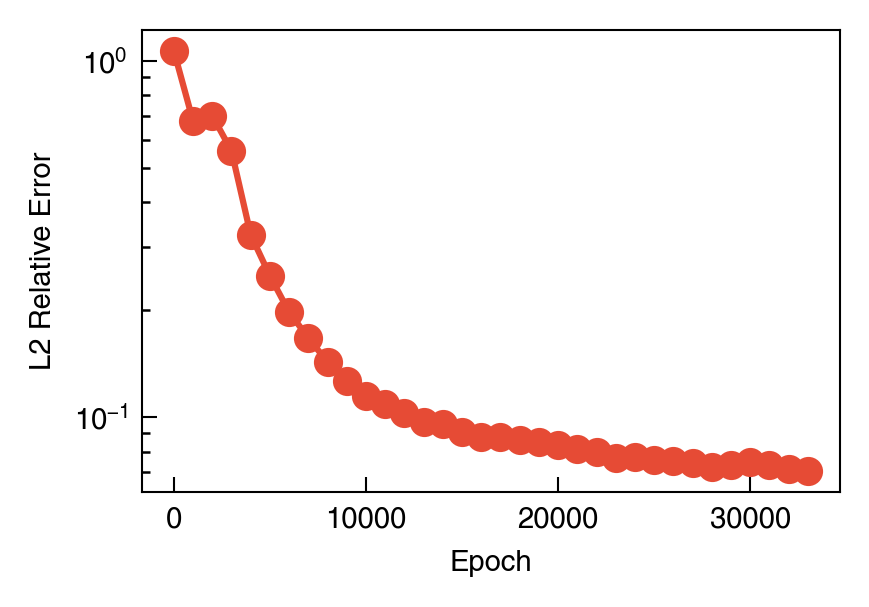

In [15]:
fig, ax = plt.subplots(figsize=(3, 2))
ax.plot(epochs, error_log, marker="o")
ax.set_xlabel("Epoch")
ax.set_ylabel("L2 Relative Error")
ax.set_yscale("log")
fig.savefig("./figures/ldc_test_l2_convergence.png", dpi=300, bbox_inches="tight", pad_inches=0.0)